# 作业一

（1）随机生成5000条股票价格曲线，画图； μ=6%, σ=13%

股票价格服从几何布朗运动：

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

离散化形式：

$$S_{t+\Delta t} = S_t \exp\left\{\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z\right\}$$

其中：
- $\mu = 6\%$ 为漂移率
- $\sigma = 13\%$ 为波动率
- $Z \sim N(0, 1)$ 为标准正态随机变量

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证可重复性
np.random.seed(42)

# 参数设置
mu = 0.06          # 漂移率 (6%)
sigma = 0.13       # 波动率 (13%)
S0 = 100           # 初始股票价格
T = 1.0            # 时间期限 (1年)
n_steps = 242      # 时间步数 (一年242个交易日)
n_paths = 5000     # 模拟路径数

# 计算时间步长
dt = T / n_steps

# 生成时间网格
t = np.linspace(0, T, n_steps + 1)

# 生成随机数
Z = np.random.standard_normal((n_paths, n_steps))

# 初始化价格矩阵
S = np.zeros((n_paths, n_steps + 1))
S[:, 0] = S0

# 使用几何布朗运动的离散化公式计算价格路径
for i in range(n_steps):
    S[:, i+1] = S[:, i] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i])

print(f"参数设置:")
print(f"  漂移率 μ = {mu*100:.1f}%")
print(f"  波动率 σ = {sigma*100:.1f}%")
print(f"  初始价格 S0 = {S0}")
print(f"  模拟路径数 = {n_paths}")
print(f"  时间步数 = {n_steps}")

参数设置:
  漂移率 μ = 6.0%
  波动率 σ = 13.0%
  初始价格 S0 = 100
  模拟路径数 = 5000
  时间步数 = 242


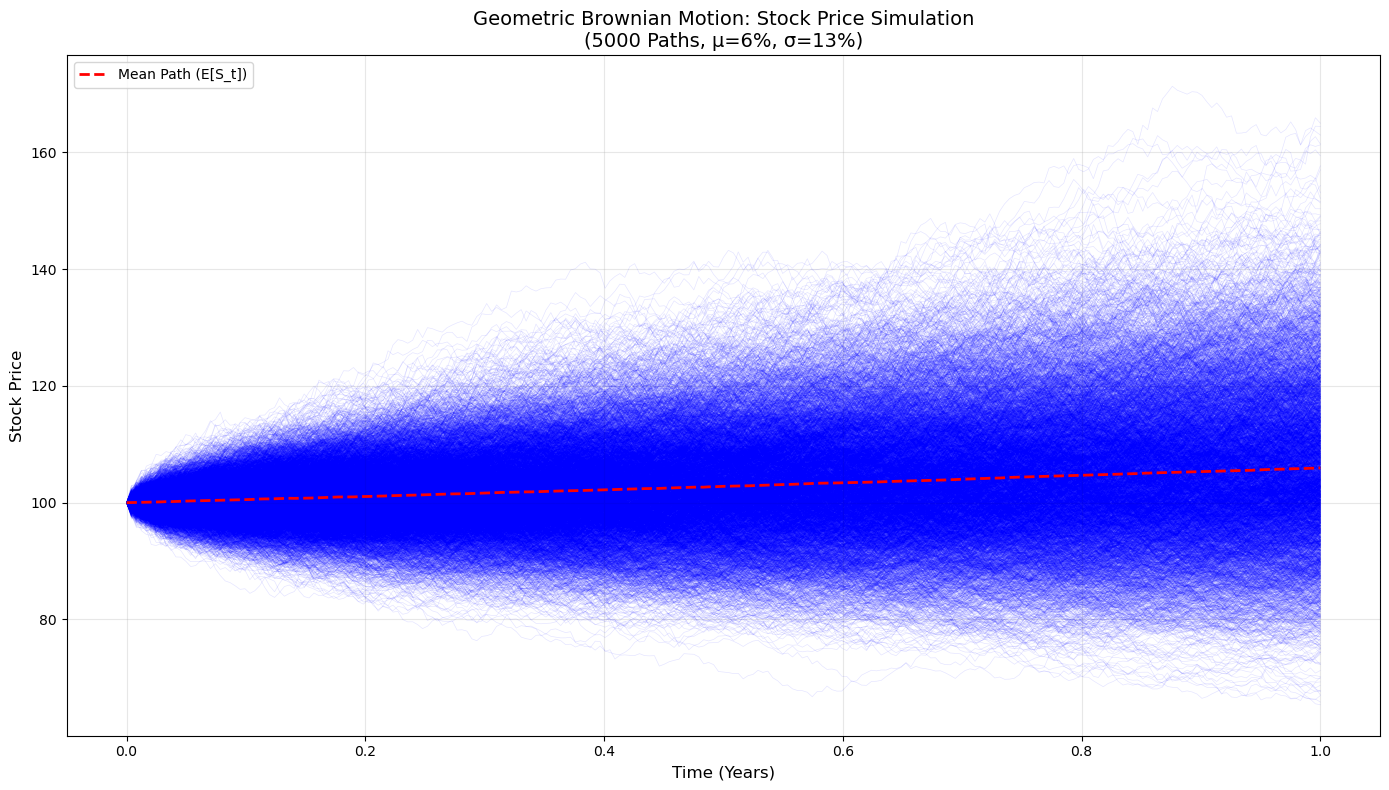

In [4]:
# 创建图形
plt.figure(figsize=(14, 8))

# 绘制所有路径 (使用半透明颜色)
for i in range(n_paths):
    plt.plot(t, S[i, :], alpha=0.1, color='blue', linewidth=0.5)

# 绘制平均路径
mean_path = np.mean(S, axis=0)
plt.plot(t, mean_path, color='red', linewidth=2, label=f'Mean Path (E[S_t])', linestyle='--')

# 设置图形属性
plt.title('Geometric Brownian Motion: Stock Price Simulation\n(5000 Paths, μ=6%, σ=13%)', fontsize=14)
plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

（2）计算每条价格曲线的年化收益率、年化波动率以及最大回撤，画出各统计指标的分布图。

In [ ]:
# 计算每条路径的统计指标

# 1. 年化收益率 (Annualized Return)
# 年化收益率 = (S_T / S_0)^(1/T) - 1
annualized_returns = (S[:, -1] / S[:, 0]) ** (1 / T) - 1

# 2. 年化波动率 (Annualized Volatility)
# 计算每日对数收益率
log_returns = np.log(S[:, 1:] / S[:, :-1])
# 年化波动率 = std(日收益率) * sqrt(年交易日数)
annualized_volatility = np.std(log_returns, axis=1) * np.sqrt(n_steps)

# 3. 最大回撤 (Maximum Drawdown)
def calculate_max_drawdown(prices):
    cumulative_max = np.maximum.accumulate(prices)
    drawdowns = (prices - cumulative_max) / cumulative_max
    return np.min(drawdowns)

max_drawdowns = np.array([calculate_max_drawdown(S[i, :]) for i in range(n_paths)])

# 打印统计信息
print("="*60)
print("统计指标汇总")
print("="*60)
print(f"\n年化收益率:")
print(f"  均值: {np.mean(annualized_returns)*100:.4f}%")
print(f"  标准差: {np.std(annualized_returns)*100:.4f}%")
print(f"  最小值: {np.min(annualized_returns)*100:.4f}%")
print(f"  最大值: {np.max(annualized_returns)*100:.4f}%")
print(f"  理论期望值: {mu*100:.4f}%")

print(f"\n年化波动率:")
print(f"  均值: {np.mean(annualized_volatility)*100:.4f}%")
print(f"  标准差: {np.std(annualized_volatility)*100:.4f}%")
print(f"  最小值: {np.min(annualized_volatility)*100:.4f}%")
print(f"  最大值: {np.max(annualized_volatility)*100:.4f}%")
print(f"  理论期望值: {sigma*100:.4f}%")

print(f"\n最大回撤:")
print(f"  均值: {np.mean(max_drawdowns)*100:.4f}%")
print(f"  标准差: {np.std(max_drawdowns)*100:.4f}%")
print(f"  最小值: {np.min(max_drawdowns)*100:.4f}%")
print(f"  最大值: {np.max(max_drawdowns)*100:.4f}%")

In [ ]:
# 绘制三个统计指标的分布图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 年化收益率分布
axes[0].hist(annualized_returns * 100, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(annualized_returns) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(annualized_returns)*100:.2f}%')
axes[0].axvline(mu * 100, color='green', linestyle='-.', linewidth=2, 
                label=f'Theoretical μ = {mu*100:.2f}%')
axes[0].set_title('Distribution of Annualized Return', fontsize=14)
axes[0].set_xlabel('Annualized Return (%)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. 年化波动率分布
axes[1].hist(annualized_volatility * 100, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.mean(annualized_volatility) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(annualized_volatility)*100:.2f}%')
axes[1].axvline(sigma * 100, color='green', linestyle='-.', linewidth=2, 
                label=f'Theoretical σ = {sigma*100:.2f}%')
axes[1].set_title('Distribution of Annualized Volatility', fontsize=14)
axes[1].set_xlabel('Annualized Volatility (%)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 3. 最大回撤分布
axes[2].hist(max_drawdowns * 100, bins=50, density=True, alpha=0.7, color='mediumseagreen', edgecolor='black')
axes[2].axvline(np.mean(max_drawdowns) * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(max_drawdowns)*100:.2f}%')
axes[2].set_title('Distribution of Maximum Drawdown', fontsize=14)
axes[2].set_xlabel('Maximum Drawdown (%)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 绘制箱线图对比
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 年化收益率箱线图
bp1 = axes[0].boxplot(annualized_returns * 100, patch_artist=True)
bp1['boxes'][0].set_facecolor('steelblue')
axes[0].axhline(mu * 100, color='green', linestyle='-.', linewidth=2, label=f'Theoretical μ = {mu*100:.2f}%')
axes[0].set_title('Annualized Return', fontsize=14)
axes[0].set_ylabel('Return (%)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# 年化波动率箱线图
bp2 = axes[1].boxplot(annualized_volatility * 100, patch_artist=True)
bp2['boxes'][0].set_facecolor('coral')
axes[1].axhline(sigma * 100, color='green', linestyle='-.', linewidth=2, label=f'Theoretical σ = {sigma*100:.2f}%')
axes[1].set_title('Annualized Volatility', fontsize=14)
axes[1].set_ylabel('Volatility (%)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# 最大回撤箱线图
bp3 = axes[2].boxplot(max_drawdowns * 100, patch_artist=True)
bp3['boxes'][0].set_facecolor('mediumseagreen')
axes[2].set_title('Maximum Drawdown', fontsize=14)
axes[2].set_ylabel('Drawdown (%)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()